In [1]:
# import
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# 상태 정의
from typing import TypedDict, List, Any

class PipelineState(TypedDict):
    messages: List[Any]        # 대화 기록
    generated_query: str       # LLM이 만든 영어 프롬프트
    generated_image: str       # 저장된 이미지 경로
    modification_count: int    # 수정 횟수
    pipeline_step: str         # 현재 파이프라인 단계
    original_dict: dict        # 초기 dictionary (자동차 요소 입력)

In [ ]:
pipe = FluxKontextPipeline.from_pretrained("black-forest-labs/FLUX.1-Kontext-dev", torch_dtype=torch.bfloat16).to("cuda")

In [42]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from datetime import datetime
import os, json
from diffusers.utils import load_image
import torch
from diffusers import FluxKontextPipeline
from PIL import Image

def save_image(image: Image.Image, filepath: str):
    """생성된 이미지를 저장합니다"""
    try:
        image.save(filepath)
    except Exception as e:
        print(f"이미지 저장 중 오류 발생: {e}")
        raise

class EnhancedImagePipeline:
    def __init__(self, save_image):
        self.save_image = save_image
        self.llm = ChatOpenAI(model="gpt-4o-mini")

    # 1. 초기 dictionary 쿼리 → 영어 프롬프트 생성
    def process_initial_query(self, state: PipelineState) -> PipelineState:
        dict_query = state["messages"][-1].content  # dictionary
        prompt = f"""
        Convert the following structured car design dictionary into a concise English prompt 
        for an image generation model (Flux). Use short descriptive words.(< 78 CLIP TOKENS)

        Dictionary:
        {json.dumps(dict_query, ensure_ascii=False)}
        """
        response = self.llm.invoke([HumanMessage(content=prompt)])
        state["generated_query"] = response.content.strip()
        state["original_dict"] = dict_query
        state["pipeline_step"] = "query_received"
        print("쿼리 수신 및 변환 완료:", state["generated_query"])
        return state

    # 2. 이미지 생성
    def generate_image(self, state: PipelineState) -> PipelineState:
        query = state["generated_query"]
    
        # 이전에 생성된 이미지 확인
        input_image = state.get("generated_image", None)
    
        # 문자열(경로)이면 PIL.Image로 변환
        if isinstance(input_image, str):
            if os.path.exists(input_image):
                input_image = load_image(input_image)
            else:
                input_image = None
    
        # 이미지 생성 (처음이면 새로 생성, 있으면 편집)
        if input_image is None:
            print("📸 새 이미지 생성 중...")
            result = pipe(
                prompt=query,
                guidance_scale=30
            )
        else:
            print("✏️ 기존 이미지를 기반으로 수정 중...")
            result = pipe(
                image=input_image,
                prompt=query,
                guidance_scale=4.5
            )
    
        # 결과 처리
        if not result.images or len(result.images) == 0:
            raise RuntimeError("❌ 이미지가 생성되지 않았습니다.")
    
        output_image = result.images[0]
    
        # 저장
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_path = f"outputs/generated_image_{timestamp}.png"
        os.makedirs("outputs", exist_ok=True)
        self.save_image(output_image, output_path)
    
        # state 업데이트
        state["generated_image"] = output_image   # PIL.Image 객체 유지
        state["output_path"] = output_path
        state["pipeline_step"] = "image_generated"
    
        print("✅ 이미지 생성 완료:", output_path)
        return state



    # 3. 이미지 설명 생성 (한국어 버전)
    def explain_image(self, state: PipelineState) -> PipelineState:
        prompt = f"""
        이 이미지는 다음 쿼리를 사용하여 생성되었습니다:
        {state["generated_query"]}

        원래 사용자가 입력한 사전(dictionary):
        {json.dumps(state["original_dict"], ensure_ascii=False)}

        위의 정보를 바탕으로, 이 이미지가 어떤 디자인 요소들
        (뷰포인트, 차체 유형, 비율, 표면, 조명, 휠, 색상 등)을
        고려하여 생성되었는지 한국어로 설명해 주세요.
        """
        response = self.llm.invoke([
            SystemMessage(content="당신은 자동차 디자인 이미지 결과를 설명하는 도우미입니다. 한국어로만 대답하세요."),
            HumanMessage(content=prompt)
        ])
        explanation = response.content.strip()
        print("\n🤖 AI 설명:\n", explanation)
        
        # 사용자 입력 직접 받기
        user_input = input("\n👉 이 이미지가 마음에 드시나요? 수정이 필요하시다면 편하게 말씀해주세요 !: ")
        state["messages"].append(AIMessage(content=explanation))
        state["messages"].append(HumanMessage(content=user_input))
        
        state["pipeline_step"] = "explanation_generated"
        return state

    # 4. 사용자 피드백 판별
    def process_feedback(self, state: PipelineState) -> PipelineState:
        last_user = [m for m in state["messages"] if isinstance(m, HumanMessage)][-1].content

        judge_prompt = f"""
        사용자가 이렇게 말했습니다: "{last_user}"

        이 발언이 수정을 원한다는 의미면 "modify"으로,
        아니면 이미지에 만족했다는 의미면 "done" 판별해 주세요.

        반드시 한 영어단어로만 답변하세요: "modify" 또는 "done"
        """
        resp = self.llm.invoke([HumanMessage(content=judge_prompt)])
        decision = resp.content.strip()

        state["pipeline_step"] = f"feedback_{decision}"
        return state

    # 5. 수정 요청 처리
    def handle_modification(self, state: PipelineState) -> PipelineState:
        # 사용자에게 수정사항 직접 입력 받기
        user_input = input("\n👉 어떤 부분을 수정하고 싶으신가요?: ")
        state["messages"].append(HumanMessage(content=user_input))

        last_user = [m for m in state["messages"] if isinstance(m, HumanMessage)][-1].content
        prompt = f"""
        Translate the following user request into English 
        for use as an image generation prompt (< 78 CLIP tokens).
        
        - Use concise and descriptive words.
        - Preserve common automotive design terms such as body type, proportions, surface, bumper, grille, lights, wheels, roofline, etc.
        - Avoid mechanical or engineering jargon unrelated to exterior design 
          (e.g., chassis, suspension, engine, transmission).
        - Make the description edit-friendly: detailed enough to reflect the modification,
          but structured so that partial changes can be applied without altering the entire image.
        
        User request: {last_user}
        """

        response = self.llm.invoke([HumanMessage(content=prompt)])
        state["generated_query"] = response.content.strip()
        state["modification_count"] = state.get("modification_count", 0) + 1
        state["pipeline_step"] = "query_modified"
        return state

    # 분기 라우팅
    def _route_by_feedback(self, state: PipelineState) -> str:
        if "feedback_modify" in state["pipeline_step"]:
            return "modify"
        return "done"

In [39]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(PipelineState)
pipeline = EnhancedImagePipeline(save_image)


workflow.add_node("process_initial_query", pipeline.process_initial_query)
workflow.add_node("generate_image", pipeline.generate_image)
workflow.add_node("explain_image", pipeline.explain_image)
workflow.add_node("process_feedback", pipeline.process_feedback)
workflow.add_node("handle_modification", pipeline.handle_modification)

workflow.set_entry_point("process_initial_query")
workflow.add_edge("process_initial_query", "generate_image")
workflow.add_edge("generate_image", "explain_image")
workflow.add_edge("explain_image", "process_feedback")

workflow.add_conditional_edges(
    "process_feedback",
    pipeline._route_by_feedback,
    {
        "modify": "handle_modification",
        "done": END
    }
)

workflow.add_edge("handle_modification", "generate_image")

graph = workflow.compile()

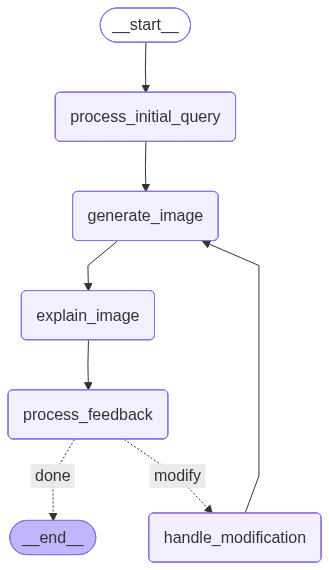

In [7]:
# 시각화
from IPython.display import Image, display
from models.flux_model import FluxImageGenerator

display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
############
#실행

init_state = PipelineState(
    messages=[HumanMessage(content="""
    {"뷰포인트": "3/4 front view",
    "차체 크기 등급": "중형",
    "차체 유형": "SUV",
    "형태": "two-box",
    "비율": "long wheelbase, short overhangs",
    "차체 표면": "clean body surfacing",
    "전면부/측면부 요소": "parametric grille",
    "조명": "pixel DRL headlamps",
    "휠/타이어": "large alloy wheels",
    "유리/그린하우스": "panoramic glass roof",
    "공기역학/추가 요소": "aerodynamic silhouette",
    "색상 & 마감": "matte silver paint"
    }""")],
    generated_query="",
    generated_image="",
    modification_count=0,
    pipeline_step="start",
    original_dict={}
)

result = graph.invoke(init_state)
result

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['matte silver paint.']


쿼리 수신 및 변환 완료: Generate an image of a mid-sized SUV in a 3/4 front view. Features include a two-box shape, long wheelbase, and short overhangs. The body has clean surfacing, a parametric grille, and pixel DRL headlamps. It sports large alloy wheels, a panoramic glass roof, and an aerodynamic silhouette. Finish the design with a matte silver paint.
📸 새 이미지 생성 중...


  0%|          | 0/28 [00:00<?, ?it/s]

✅ 이미지 생성 완료: outputs/generated_image_20250829_082620.png

🤖 AI 설명:
 이 이미지는 중형 SUV의 3/4 전면 뷰를 기반으로 하여 디자인되었습니다. 다음과 같은 주요 요소들이 포함되어 있습니다:

1. **차체 크기 등급**: 중형 SUV로 설계되어 있어, 도심주행과 장거리 여행 모두에 적합한 크기를 가집니다.
   
2. **차체 유형**: 두 상자로 구성된 형태(two-box shape)를 특징으로 하여, 공간 활용성이 뛰어납니다.

3. **비율**: 긴 휠베이스(long wheelbase)와 짧은 오버행(short overhangs)으로 안정감 있는 비율을 유지하여 주행 성능을 향상시킵니다.

4. **차체 표면**: 깨끗한 표면 처리를 통해 현대적이고 세련된 외관을 구현하였습니다.

5. **전면부 요소**: 파라메트릭 그릴(parametric grille)을 적용하여 독창적이며 기능적인 디자인 요소를 더했습니다.

6. **조명**: 픽셀 DRL 헤드램프(pixel DRL headlamps)는 미래지향적인 느낌을 주며, 시각적으로도 매력적입니다.

7. **휠**: 큰 알로이 휠(large alloy wheels)을 장착하여 SUV의 강인함과 도로에서의 존재감을 강조하고 있습니다.

8. **유리/그린하우스**: 파노라마 유리 지붕(panoramic glass roof)은 탑승자에게 넓은 시야를 제공하고 고급스러운 느낌을 줍니다.

9. **공기역학적 요소**: 공기역학적인 실루엣(aerodynamic silhouette)을 통해 연료 효율성을 높이고, 더욱 역동적인 주행 성능을 나타냅니다.

10. **색상 및 마감**: 매트 실버(Matte silver) 페인트로 마감하여 세련된 느낌과 현대적인 이미지를 강조합니다.

이러한 디자인 요소들이 조화를 이루어 전체적으로 현대적이고 혁신적인 중형 SUV 이미지를 형성하고 있습니다.



👉 이 이미지가 마음에 드시나요? 수정이 필요하시다면 편하게 말씀해주세요 !:  수정

👉 어떤 부분을 수정하고 싶으신가요?:  SUV 대신 세단 비율로 바꿔줘


...

✏️ 기존 이미지를 기반으로 수정 중...


  0%|          | 0/28 [00:00<?, ?it/s]

✅ 이미지 생성 완료: outputs/generated_image_20250829_082917.png

🤖 AI 설명:
 이 이미지는 SUV 형태의 차량 디자인으로, 다음과 같은 디자인 요소들을 고려하여 생성되었습니다.

1. **뷰포인트**: 3/4 전면뷰로, 차량의 외형이 측면과 전면이 함께 드러나는 각도에서 표현되었습니다. 이를 통해 차량의 전체적인 스타일과 역동성을 강조하고 있습니다.

2. **차체 크기 등급**: 중형 SUV로 설정되어, 도심과 여유로운 주행에 적합한 실용성을 갖추고 있습니다.

3. **차체 유형**: 두 박스(two-box) 디자인으로, 전통적인 SUV의 형태를 유지하면서도 현대적인 감각을 추가했습니다.

4. **비율**: 긴 휠베이스와 짧은 오버행으로 균형 잡힌 비율을 제시하여 안정적이고 역동적인 느낌을 줍니다.

5. **차체 표면**: 매끄럽고 깨끗한 차체 표면 처리가 돋보이며, 세련된 이미지를 긋습니다.

6. **전면부/측면부 요소**: 매개체 그릴(parametric grille)이 적용되어, 현대적인 느낌과 함께 독창적인 디자인 요소를 추가했습니다.

7. **조명**: 픽셀 DRL 헤드램프는 독특한 조명 디자인으로 주목성을 높이며, 전체적인 시각적 인상을 강화합니다.

8. **휠/타이어**: 대형 합금 휠을 장착하여, SUV의 파워풀한 이미지를 강조하고 있습니다.

9. **유리/그린하우스**: 파노라마 유리 지붕으로 장착되어, 차량 내부의 개방감과 고급스러운 느낌을 제공합니다.

10. **공기역학/추가 요소**: 공기역학적인 실루엣을 통해 연비 효율과 주행 안정성을 향상시켰습니다.

11. **색상 & 마감**: 매트 실버 도장으로 차별화된 외관을 제공하며, 현대적이고 세련된 느낌을 자아냅니다.

이 모든 요소들이 결합되어, 세련된 디자인과 기능성을 갖춘 중형 SUV가 탄생하게 된 것입니다.



👉 이 이미지가 마음에 드시나요? 수정이 필요하시다면 편하게 말씀해주세요 !:  


{'messages': [HumanMessage(content='\n    {"뷰포인트": "3/4 front view",\n    "차체 크기 등급": "중형",\n    "차체 유형": "SUV",\n    "형태": "two-box",\n    "비율": "long wheelbase, short overhangs",\n    "차체 표면": "clean body surfacing",\n    "전면부/측면부 요소": "parametric grille",\n    "조명": "pixel DRL headlamps",\n    "휠/타이어": "large alloy wheels",\n    "유리/그린하우스": "panoramic glass roof",\n    "공기역학/추가 요소": "aerodynamic silhouette",\n    "색상 & 마감": "matte silver paint"\n    }', additional_kwargs={}, response_metadata={}),
  AIMessage(content='이 이미지는 중형 SUV의 3/4 전면 뷰를 기반으로 하여 디자인되었습니다. 다음과 같은 주요 요소들이 포함되어 있습니다:\n\n1. **차체 크기 등급**: 중형 SUV로 설계되어 있어, 도심주행과 장거리 여행 모두에 적합한 크기를 가집니다.\n   \n2. **차체 유형**: 두 상자로 구성된 형태(two-box shape)를 특징으로 하여, 공간 활용성이 뛰어납니다.\n\n3. **비율**: 긴 휠베이스(long wheelbase)와 짧은 오버행(short overhangs)으로 안정감 있는 비율을 유지하여 주행 성능을 향상시킵니다.\n\n4. **차체 표면**: 깨끗한 표면 처리를 통해 현대적이고 세련된 외관을 구현하였습니다.\n\n5. **전면부 요소**: 파라메트릭 그릴(parametric grille)을 적용하여 독창적이며 기능적인 디자인 요소를 더했습니다.\n\n6. **조명**: 픽셀 DRL 헤드램프(pixel DRL 

In [ ]:
import torch
from diffusers import ShapEImg2ImgPipeline
from diffusers.utils import export_to_gif, load_image


ckpt_id = "openai/shap-e-img2img"
pipe = ShapEImg2ImgPipeline.from_pretrained(repo).to("cuda")

img_url = "https://hf.co/datasets/diffusers/docs-images/resolve/main/shap-e/corgi.png"
image = load_image(img_url)


generator = torch.Generator(device="cuda").manual_seed(0)
batch_size = 4
guidance_scale = 3.0

images = pipe(
    image, 
    num_images_per_prompt=batch_size, 
    generator=generator, 
    guidance_scale=guidance_scale,
    num_inference_steps=64, 
    size=256, 
    output_type="pil"
).images

gif_path = export_to_gif(images, "corgi_sampled_3d.gif")